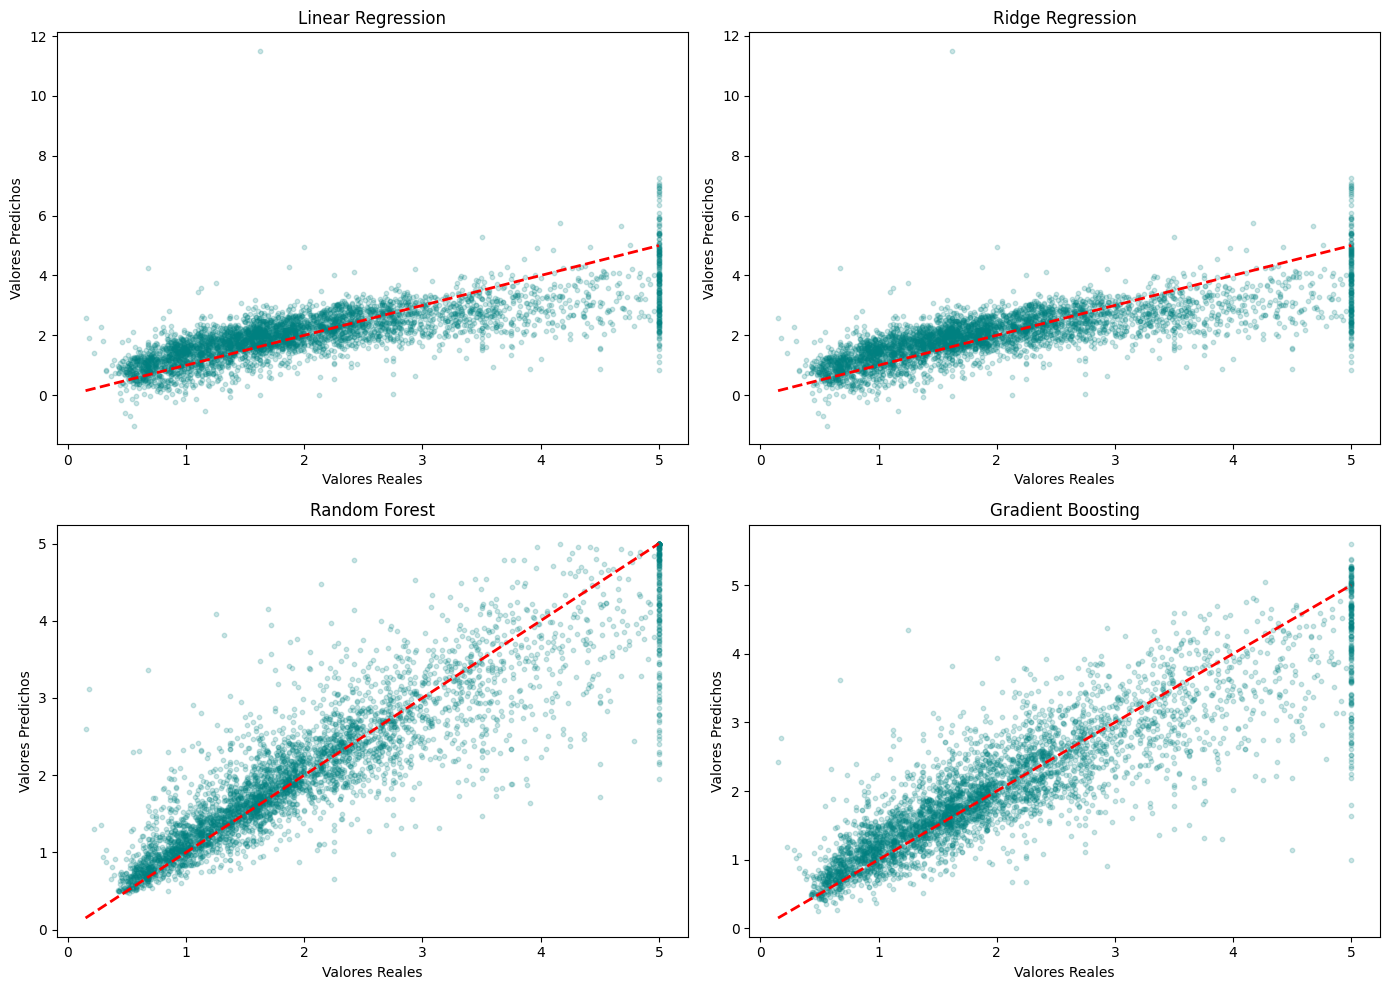


=== TABLA COMPARATIVA DE MODELOS DE REGRESIÓN ===


,mae,mse,rmse,mape,smape
Linear Regression,0.5332,0.5559,0.7456,31.9522,0.4843
Ridge Regression,0.5332,0.5559,0.7456,31.9512,0.4843
Random Forest,0.3301,0.2570,0.5070,19.0086,0.3194
Gradient Boosting,0.3717,0.2940,0.5422,21.5266,0.3543


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. DEFINICIÓN DE LAS FUNCIONES DE MÉTRICAS (Requeridas por el enunciado)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df_input):
    df_result = pd.DataFrame()
    y_true = df_input['y']
    y_pred = df_input['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]
    return df_result

# 2. CARGAR LOS DATOS ORIGINALES
housing_data = fetch_california_housing(as_frame=True)
housing = housing_data['data']
housing['target'] = housing_data['target']

# 3. PREPROCESAMIENTO
X_reg = housing.drop(columns=['target']).values
y_reg = housing['target'].values

# Dividir en entrenamiento y testeo (80/20)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Escalar los datos (Normalización)
scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

# 4. ENTRENAMIENTO DE LOS 4 MODELOS
modelos_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

metricas_consolidadas = []
plt.figure(figsize=(14, 10))

for i, (nombre, model) in enumerate(modelos_reg.items(), 1):
    # Ajustar modelo
    model.fit(X_train_r, y_train_r)
    # Predecir
    y_pred = model.predict(X_test_r)

    # Calcular métricas con la función oficial
    df_temp = pd.DataFrame({'y': y_test_r, 'yhat': y_pred})
    metricas_modelo = regression_metrics(df_temp)
    metricas_modelo.index = [nombre]
    metricas_consolidadas.append(metricas_modelo)

    # Graficar resultados (Predicho vs Real)
    plt.subplot(2, 2, i)
    plt.scatter(y_test_r, y_pred, alpha=0.2, color='teal', s=10)
    plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
    plt.title(f"{nombre}")
    plt.xlabel('Valores Reales')
    plt.ylabel('Valores Predichos')

plt.tight_layout()
plt.show()

# 5. MOSTRAR LA TABLA COMPARATIVA FINAL
df_metricas_reg = pd.concat(metricas_consolidadas)
print("\n=== TABLA COMPARATIVA DE MODELOS DE REGRESIÓN ===")
display(df_metricas_reg)

=== EJERCICIO 1: DATOS EXPLORATORIOS ===
Uso de memoria aproximado: 912.67 KB
Tipos de datos únicos en las columnas: [dtype('int64')]

Registros disponibles por cada dígito (Clase):
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

=== EJERCICIO 2: VISUALIZACIÓN DE DÍGITOS ===


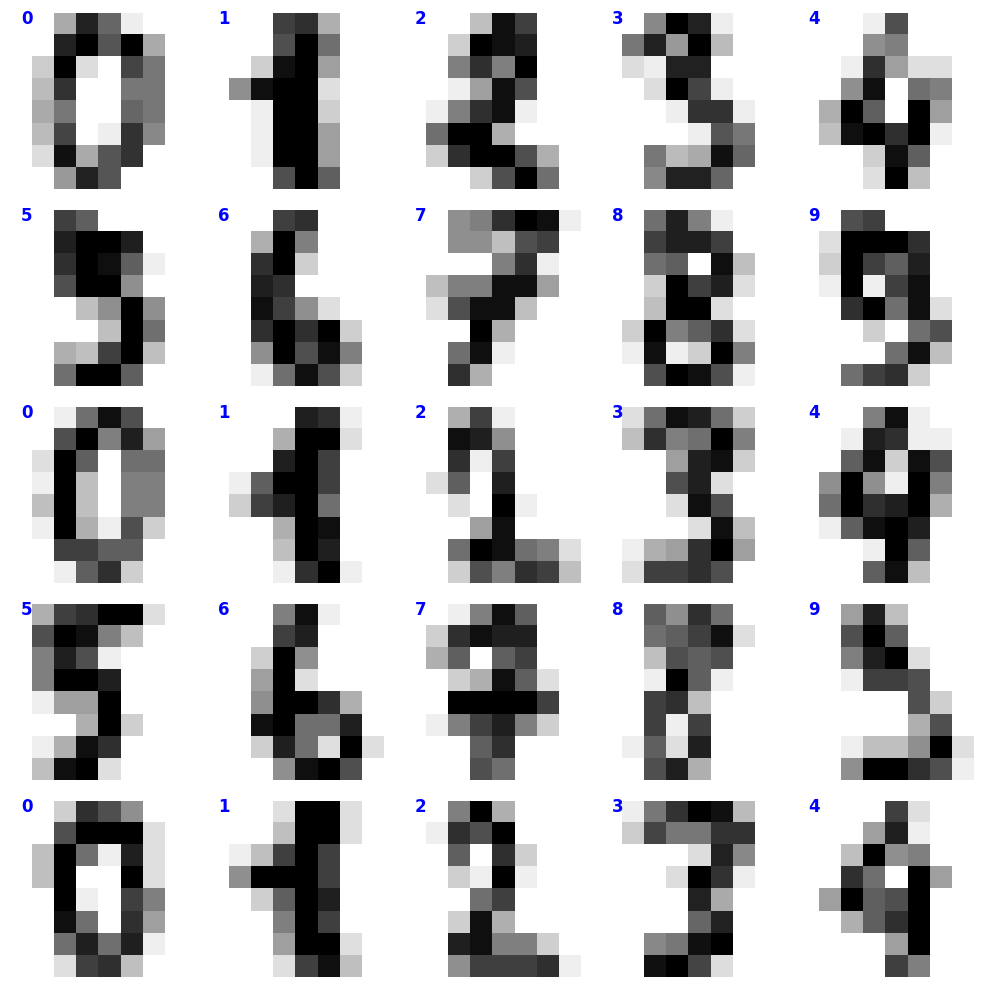

In [3]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

# 1. Cargar el diccionario original
digits_dict = datasets.load_digits()

# 2. Reconstruir el DataFrame 'digits' estructurado con nombres c00, c01...
digits = (
    pd.DataFrame(digits_dict["data"])
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

print("=== EJERCICIO 1: DATOS EXPLORATORIOS ===")
print(f"Uso de memoria aproximado: {digits.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"Tipos de datos únicos en las columnas: {digits.dtypes.unique()}")
print("\nRegistros disponibles por cada dígito (Clase):")
print(digits['target'].value_counts().sort_index())

print("\n=== EJERCICIO 2: VISUALIZACIÓN DE DÍGITOS ===")
nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(10, 10))

for i in range(nx * ny):
    row = i // ny
    col = i % ny

    # Redimensionar el vector plano de 64 a una matriz de 8x8 pixeles
    img = digits_dict["images"][i]
    label = digits_dict["target"][i]

    axs[row, col].imshow(img, interpolation='nearest', cmap='gray_r')
    axs[row, col].text(0, 0, str(label), color='blue', fontweight='bold', fontsize=12)
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()

Largo conjunto entrenamiento (Train): 1437
Largo conjunto testeo (Test): 360


==================== Logistic Regression ====================
Tiempo empleado en ajustar: 5.0057 segundos
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.92      0.96      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.98       360



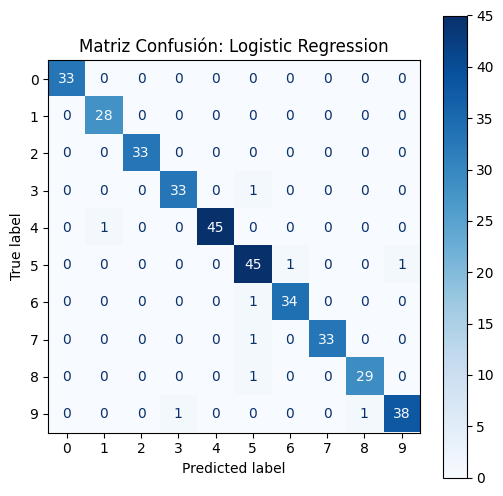


==================== K-Nearest Neighbors ====================
Tiempo empleado en ajustar: 0.0021 segundos
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



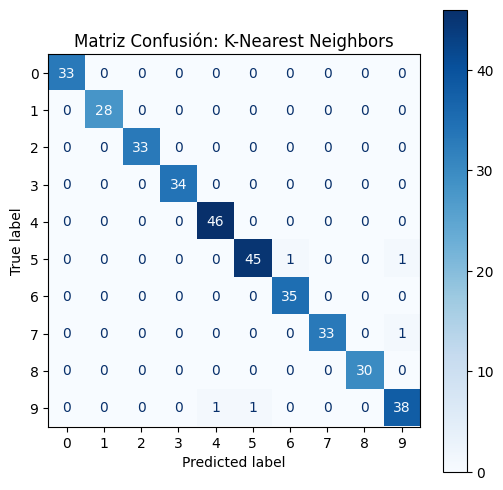


==================== Support Vector Machine ====================
Tiempo empleado en ajustar: 1.0551 segundos
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



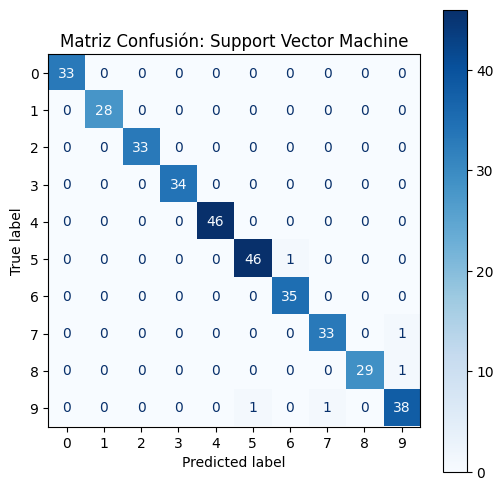

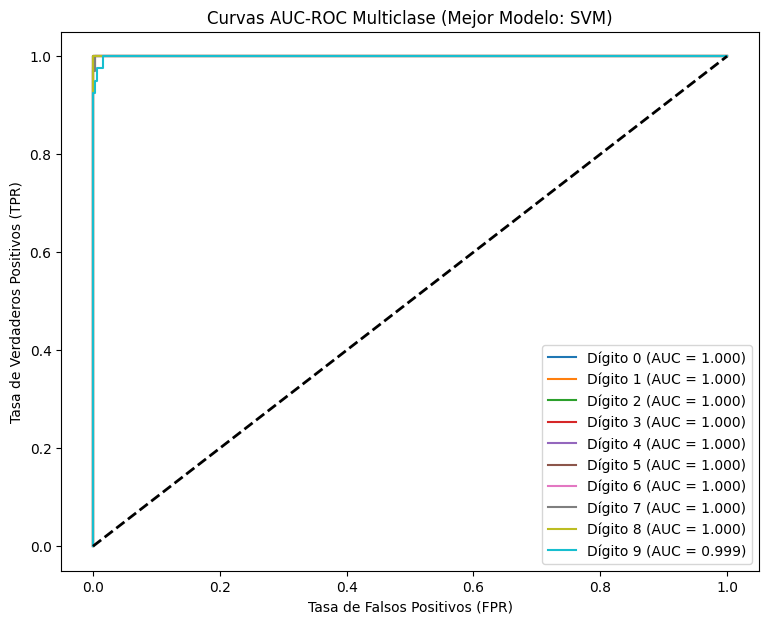

In [4]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Separar características y etiquetas
X = digits.drop(columns="target").values
y = digits["target"].values

# Dividir el dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Largo conjunto entrenamiento (Train): {len(X_train)}")
print(f"Largo conjunto testeo (Test): {len(X_test)}\n")

# Instanciar modelos
modelos_clf = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(probability=True, random_state=42)
}

# Entrenar y evaluar
for nombre, model in modelos_clf.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    t_ajuste = time.time() - start_time

    y_pred = model.predict(X_test)

    print(f"\n==================== {nombre} ====================")
    print(f"Tiempo empleado en ajustar: {t_ajuste:.4f} segundos")
    print(classification_report(y_test, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(f"Matriz Confusión: {nombre}")
    ax.grid(False)
    plt.show()

# --- EJERCICIO 4: Curva AUC-ROC para el mejor modelo (Support Vector Machine) ---
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Obtener probabilidades estimadas del modelo SVM
best_model = modelos_clf['Support Vector Machine']
y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(9, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Dígito {i} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas AUC-ROC Multiclase (Mejor Modelo: SVM)')
plt.legend(loc="lower right")
plt.show()

=== CASOS DONDE EL VALOR PREDICHO Y EL ORIGINAL SON IGUALES ===


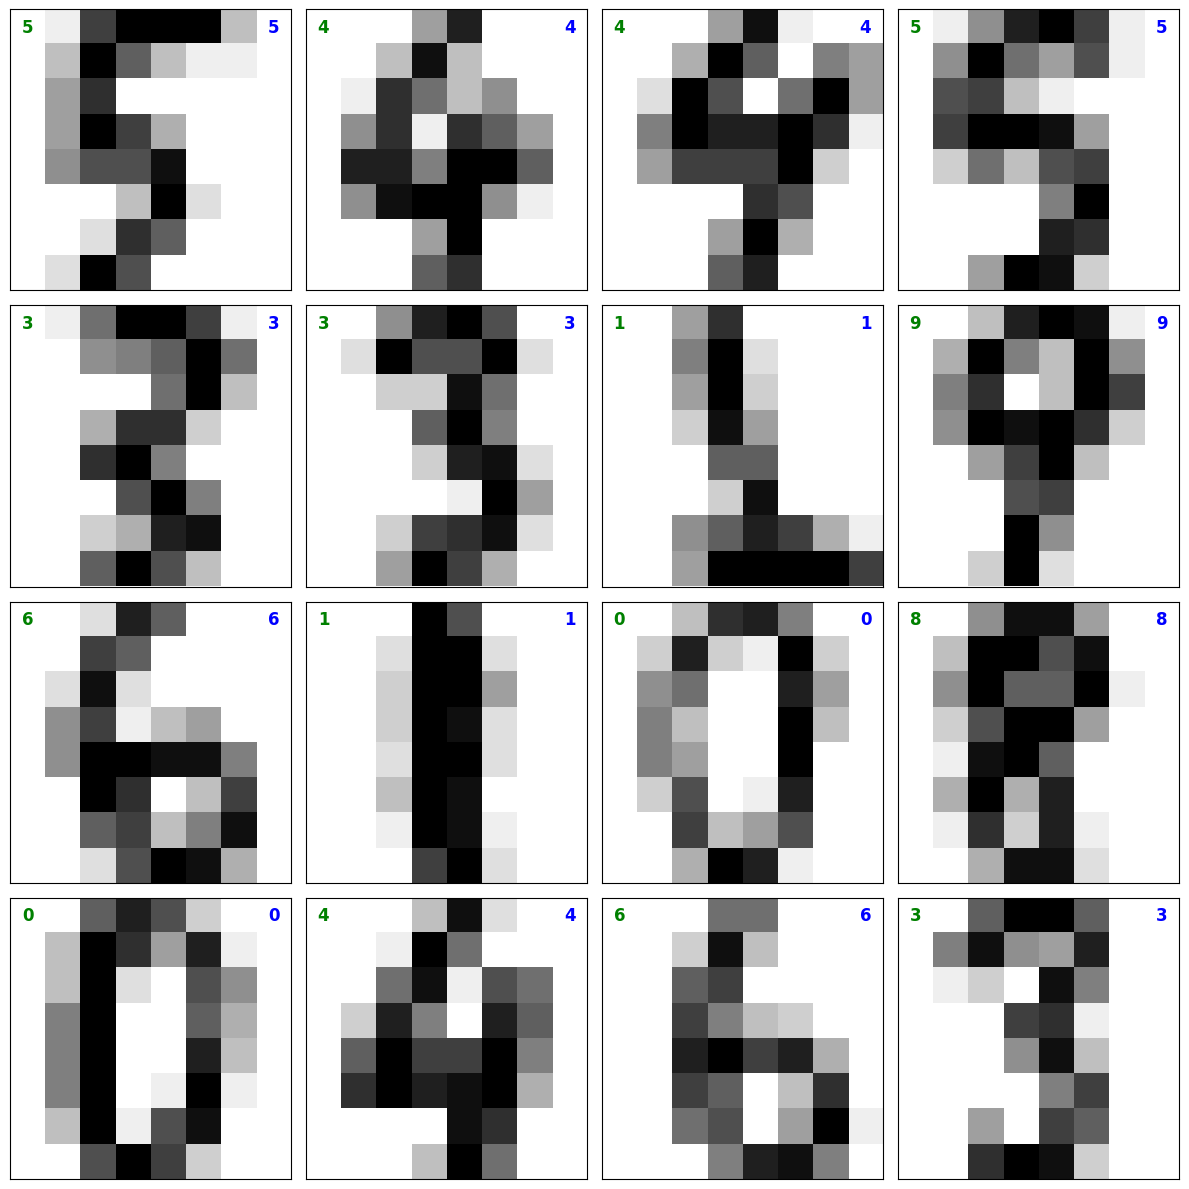


=== CASOS DONDE EL VALOR PREDICHO Y EL ORIGINAL SON DISTINTOS ===


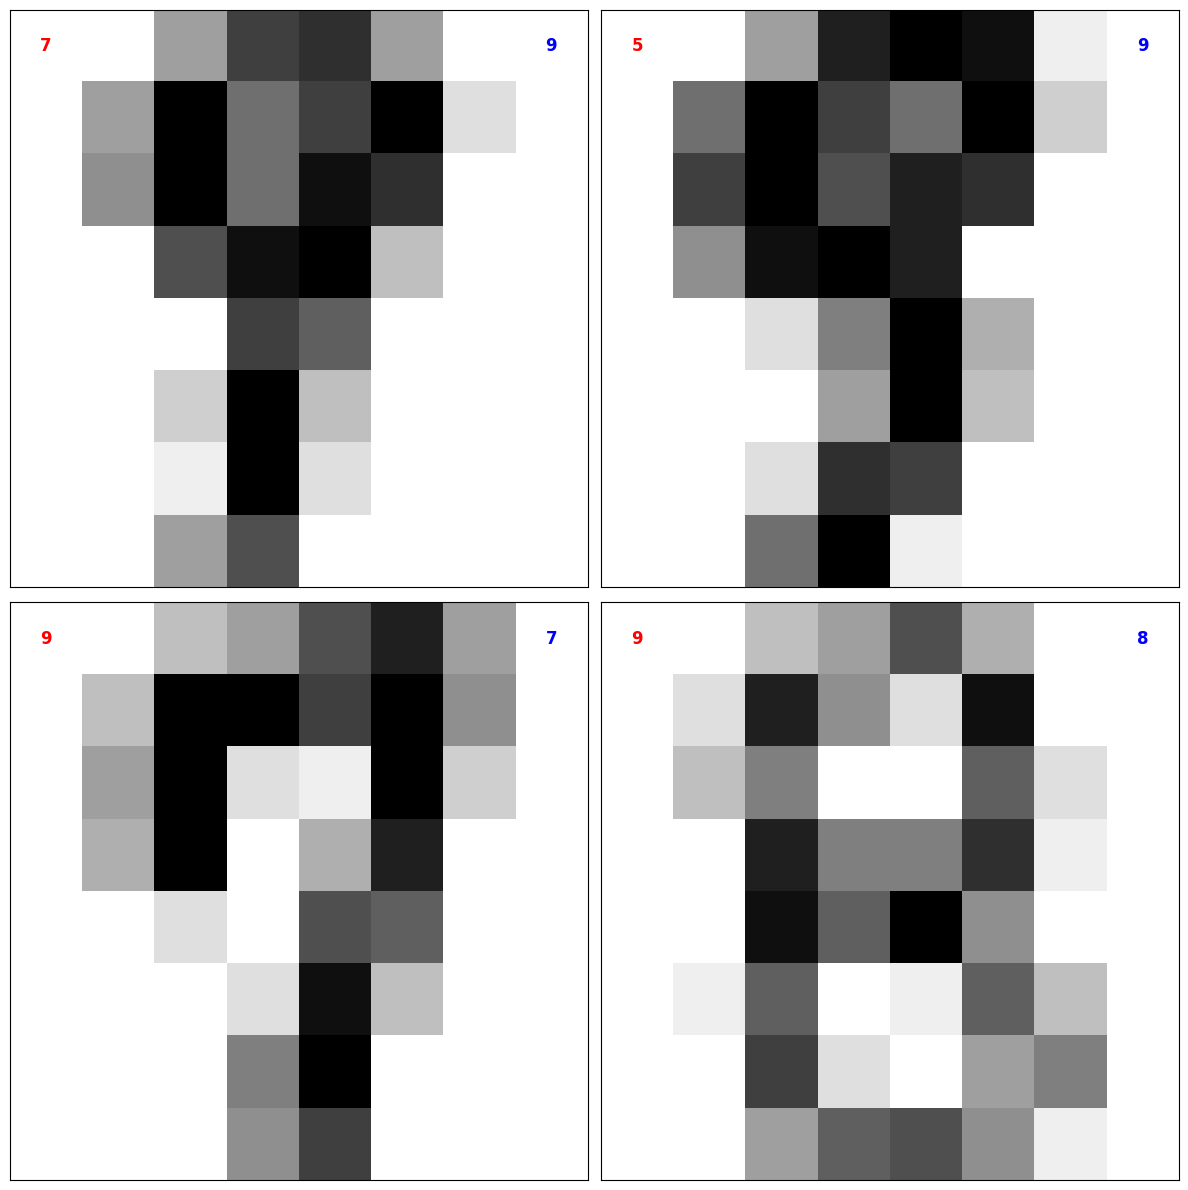

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# ==============================================================================
# 1. ASEGURAMOS QUE LA FUNCIÓN DEL PROFESOR ESTÉ BIEN DECLARADA EN ESTA CELDA
# ==============================================================================
def mostrar_resultados(digits_df, model, nx=5, ny=5, label="correctos"):
    X = digits_df.drop(columns="target").values
    y = digits_df["target"].values

    # Aquí es donde fallaba si no se importaba train_test_split arriba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"
    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    if len(X_aux) == 0:
        print(f"¡Increíble! No hay muestras para la categoría '{label}'. El modelo obtuvo un desempeño perfecto en este subset.")
        return

    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    # Manejar el caso si la grilla es de 1x1 para evitar errores de indexación
    if nx == 1 and ny == 1:
        ax = np.array([[ax]])
    elif nx == 1 or ny == 1:
        ax = ax.reshape(nx, ny)

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=12, color=color, fontweight='bold')
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=12, color='blue', fontweight='bold')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 2. EJECUTAMOS LAS VISUALIZACIONES REQUERIDAS
# ==============================================================================
print("=== CASOS DONDE EL VALOR PREDICHO Y EL ORIGINAL SON IGUALES ===")
mostrar_resultados(digits, SVC(probability=True, random_state=42), nx=4, ny=4, label="correctos")

print("\n=== CASOS DONDE EL VALOR PREDICHO Y EL ORIGINAL SON DISTINTOS ===")
mostrar_resultados(digits, SVC(probability=True, random_state=42), nx=2, ny=2, label="incorrectos")